In [16]:
# Import libraries
import numpy as np
import pandas as pd
import scipy
from scipy import special
from pathlib import Path
import scipy.sparse as sp
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, norm

Nout = 100000  # number of out-of-sample scenarios
Nin = 5000     # number of in-sample scenarios
Ns = 5         # number of idiosyncratic scenarios for each systemic

C = 8          # number of credit states

# Read and parse instrument data
instr_data = np.array(pd.read_csv('instrum_data.csv', header=None))
instr_id = instr_data[:, 0]     # ID
driver = instr_data[:, 1]       # credit driver
beta = instr_data[:, 2]         # beta (sensitivity to credit driver)
recov_rate = instr_data[:, 3]   # expected recovery rate
value = instr_data[:, 4]        # value
prob = instr_data[:, 5:(5 + C)] # credit-state migration probabilities (default to AAA)
exposure = instr_data[:, 5 + C:5 + 2 * C]  # credit-state migration exposures (default to AAA)
retn = instr_data[:, 5 + 2 * C] # market returns

K = instr_data.shape[0]         # number of CPs

# Read matrix of correlations for credit drivers
rho = np.array(pd.read_csv('credit_driver_corr.csv', sep='\t', header=None))
# Cholesky decomp of rho (for generating correlated Normal random numbers)
sqrt_rho = np.linalg.cholesky(rho)

print('======= Credit Risk Model with Credit-State Migrations =======')
print('============== Monte Carlo Scenario Generation ===============')
print(' ')
print(' ')
print(' Number of out-of-sample Monte Carlo scenarios = ' + str(Nout))
print(' Number of in-sample Monte Carlo scenarios = ' + str(Nin))
print(' Number of counterparties = ' + str(K))
print(' ')

======= Credit Risk Model with Credit-State Migrations =======
============== Monte Carlo Scenario Generation ===============
 
 
 Number of out-of-sample Monte Carlo scenarios = 100000
 Number of in-sample Monte Carlo scenarios = 5000
 Number of counterparties = 100
 


In [17]:
# Find credit-state for each counterparty
# 8 = AAA, 7 = AA, 6 = A, 5 = BBB, 4 = BB, 3 = B, 2 = CCC, 1 = default
CS = np.argmax(prob, axis=1) + 1

# Account for default recoveries
exposure[:, 0] = (1 - recov_rate) * exposure[:, 0]

# Compute credit-state boundaries
CS_Bdry = scipy.special.ndtri((np.cumsum(prob[:, 0:C - 1], 1)))

# Saving out-of-sample results to file
filename_save_out = 'losses_out'

# Get number of systemic factors from correlation matrix
num_drivers = rho.shape[0]
driver_idx = np.int32(driver) - 1

# Reshape beta into row vector and pre-calculate idiosyncratic weights
beta_arr = beta.reshape(1, -1)
sqrt_1_beta2 = np.sqrt(1 - beta**2).reshape(1, -1)

if Path(filename_save_out+'.npz').is_file():
    Losses_out = scipy.sparse.load_npz(filename_save_out + '.npz')
else:
    # Generating Scenarios

    # Generate 100,000 rows of correlated systemic shocks using Cholesky factor
    Y_shocks = np.random.normal(0, 1, (Nout, num_drivers)) @ sqrt_rho.T

    # Share systemic shocks so each of 100 bonds is linked to its specific driver
    Y_mapped = Y_shocks[:, driver_idx]

    # Create idiosyncratic noise for every bond in every scenario
    Epsilon = np.random.normal(0, 1, (Nout, K))

    # Latest asset return variable (combines systemic and idiosyncratic drivers)
    Z = beta_arr * Y_mapped + sqrt_1_beta2 * Epsilon

    # Pre-allocate a matrix to hold loss amounts
    Losses_out_arr = np.zeros((Nout, K))

    # Loop through each counterparty to find their asset returns and compute credit states
    for i in range(K):
        state_idx = np.searchsorted(CS_Bdry[i, :], Z[:, i])
        Losses_out_arr[:, i] = exposure[i, state_idx]
    Losses_out = sp.csr_matrix(Losses_out_arr)
    sp.save_npz(filename_save_out, Losses_out)

    # Don't need this loop since we aren't going one-by-one (used a vectorized approach to compute all at once)
    # for s in range(1, Nout + 1):
    #     pass

    #     # Calculated out-of-sample losses (100000 x 100)
    #     # Losses_out (sparse matrix)
    #     Losses_out = Losses_out

In [18]:
# Normal approximation computed from out-of-sample scenarios
mu_l = np.mean(Losses_out, axis=0).reshape((K))
var_l = np.cov(Losses_out.toarray(), rowvar=False) # Losses_out as a sparse matrix

# Compute portfolio weights
portf_v = sum(value)  # portfolio value
w0 = []
w0.append(value / portf_v)   # asset weights (portfolio 1)
w0.append(np.ones((K)) / K)  # asset weights (portfolio 2)
x0 = []
x0.append((portf_v / value) * w0[0])  # asset units (portfolio 1)
x0.append((portf_v / value) * w0[1])  # asset units (portfolio 2)

# Quantile levels (99%, 99.9%)
alphas = np.array([0.99, 0.999])

VaRout = np.zeros((2, alphas.size))
VaRinN = np.zeros((2, alphas.size))
CVaRout = np.zeros((2, alphas.size))
CVaRinN = np.zeros((2, alphas.size))

for portN in range(2):
    # Compute VaR and CVaR
    portf_loss_out = np.sort(np.array(Losses_out.dot(x0[portN])).flatten())
    mu_p = np.dot(mu_l, x0[portN]).item()
    sigma_p = np.sqrt(np.dot(x0[portN].T, np.dot(var_l, x0[portN]))).item()

    for q in range(alphas.size):
        alf = alphas[q]
        # Find specific scenarios that correspond to 99% or 99.9% quantile
        var_idx = int(np.ceil(alf * Nout)) - 1

        # Save Z-score for target quantile
        z_alpha = norm.ppf(alf).item()

        # Find the real Value At Risk using sorted out-of-sample loss data
        VaRout[portN, q] = portf_loss_out[var_idx]

        # Calculate Value At Risk if a Normal distribution was assumed
        VaRinN[portN, q] = mu_p + z_alpha * sigma_p

        # Average out all losses that are beyond the Value At Risk
        CVaRout[portN, q] = (1 / (Nout * (1 - alf))) * ((var_idx + 1 - Nout * alf) * portf_loss_out[var_idx] + np.sum(portf_loss_out[var_idx + 1:]))

        # Use Expected Shortfall formula for Normal distribution computation
        CVaRinN[portN, q] = mu_p + sigma_p * (norm.pdf(z_alpha).item() / (1 - alf))

In [19]:
# Perform 100 trials
N_trials = 100

VaRinMC1 = {}
VaRinMC2 = {}
VaRinN1 = {}
VaRinN2 = {}
CVaRinMC1 = {}
CVaRinMC2 = {}
CVaRinN1 = {}
CVaRinN2 = {}

for portN in range(2):
    for q in range(alphas.size):
        VaRinMC1[portN, q] = np.zeros(N_trials)
        VaRinMC2[portN, q] = np.zeros(N_trials)
        VaRinN1[portN, q] = np.zeros(N_trials)
        VaRinN2[portN, q] = np.zeros(N_trials)
        CVaRinMC1[portN, q] = np.zeros(N_trials)
        CVaRinMC2[portN, q] = np.zeros(N_trials)
        CVaRinN1[portN, q] = np.zeros(N_trials)
        CVaRinN2[portN, q] = np.zeros(N_trials)

print(f"Running {N_trials} in-sample trials")

for tr in range(1, N_trials + 1):
    # Monte Carlo approximation 1
    # 1000 Systemic x 5 Idiosyncratic = 5000 Scenarios
    # Creating 1000 unique systemic shocks
    Y_sys_MC1 = np.random.normal(0, 1, (int(Nin/Ns), num_drivers)) @ sqrt_rho.T

    # Repeat each shock 5 times to get 5000 scenarios
    Y_shocks_MC1 = np.repeat(Y_sys_MC1, Ns, axis=0)

    # Calculate asset returns
    Z_MC1 = beta_arr * Y_shocks_MC1[:, driver_idx] + sqrt_1_beta2 * np.random.normal(0, 1, (Nin, K))

    # Find the dollar loss based on the pre-computed states
    L_trial1 = np.zeros((Nin, K))
    for i in range(K):
        L_trial1[:, i] = exposure[i, np.searchsorted(CS_Bdry[i, :], Z_MC1[:, i])]

    # Convert to sparse matrix
    Losses_inMC1 = sp.csr_matrix(L_trial1)

    # Not necessary code since instead of looping through each iteration, we are doing a SIMD computation with entire loss matrix
    # for s in range(1, np.int32(np.ceil(Nin / Ns) + 1)): # systemic scenarios
    #     # -------- Insert your code here -------- #
    #     pass
    #     for si in range(1, Ns + 1): # idiosyncratic scenarios for each systemic
    #         # -------- Insert your code here -------- #
    #         pass

    # Monte Carlo approximation 2
    # 5000 Systemic x 1 Idiosyncratic = 5000 Scenarios
    # Create 5000 systemic shocks
    Y_shocks_MC2 = np.random.normal(0, 1, (Nin, num_drivers)) @ sqrt_rho.T

    # Compute asset returns for each scenario
    Z_MC2 = beta_arr * Y_shocks_MC2[:, driver_idx] + sqrt_1_beta2 * np.random.normal(0, 1, (Nin, K))

    # Find the dollar loss based on the pre-computed states
    L_trial2 = np.zeros((Nin, K))
    for i in range(K):
        L_trial2[:, i] = exposure[i, np.searchsorted(CS_Bdry[i, :], Z_MC2[:, i])]

    # Store results in matrix
    Losses_inMC2 = sp.csr_matrix(L_trial2)

    # Don't need to iterate since we are using a SIMD (single-instruction-multiple-device) matrix approach
    # for s in range(1, Nin + 1): # systemic scenarios (1 idiosyncratic scenario for each systemic)
    #     # -------- Insert your code here -------- #
    #     pass

    # Compute VaR and CVaR
    for portN in range(2):
        # Sort losses for empirical quantiles
        portf_loss_inMC1 = np.sort(np.array(Losses_inMC1.dot(x0[portN])).flatten())
        portf_loss_inMC2 = np.sort(np.array(Losses_inMC2.dot(x0[portN])).flatten())

        # Trial statistics for Normal approximations
        # NOTE: Using statistics from the final trial for MC1/MC2 Normal approximation in plots
        mu_MC1 = np.mean(L_trial1, axis=0)
        var_MC1 = np.cov(L_trial1, rowvar=False)
        mu_MC2 = np.mean(L_trial2, axis=0)
        var_MC2 = np.cov(L_trial2, rowvar=False)

        for q in range(alphas.size):
            alf = alphas[q]
            idx = int(np.ceil(alf * Nin)) - 1
            z = norm.ppf(alf).item()
            phi_z = norm.pdf(z).item()

            # Empirical MC1 & MC2
            VaRinMC1[portN, q][tr - 1] = portf_loss_inMC1[idx]
            VaRinMC2[portN, q][tr - 1] = portf_loss_inMC2[idx]
            CVaRinMC1[portN, q][tr - 1] = (1 / (Nin * (1 - alf))) * ((idx + 1 - Nin * alf) * portf_loss_inMC1[idx] + np.sum(portf_loss_inMC1[idx + 1:]))
            CVaRinMC2[portN, q][tr - 1] = (1 / (Nin * (1 - alf))) * ((idx + 1 - Nin * alf) * portf_loss_inMC2[idx] + np.sum(portf_loss_inMC2[idx + 1:]))

            # Normal Approximation N1 (based on MC1)
            mu_p1 = np.dot(mu_MC1, x0[portN]).item()
            sig_p1 = np.sqrt(np.dot(x0[portN].T, np.dot(var_MC1, x0[portN]))).item()
            VaRinN1[portN, q][tr - 1] = mu_p1 + z * sig_p1
            CVaRinN1[portN, q][tr - 1] = mu_p1 + sig_p1 * (phi_z / (1 - alf))

            # Normal Approximation N2 (based on MC2)
            mu_p2 = np.dot(mu_MC2, x0[portN]).item()
            sig_p2 = np.sqrt(np.dot(x0[portN].T, np.dot(var_MC2, x0[portN]))).item()
            VaRinN2[portN, q][tr - 1] = mu_p2 + z * sig_p2
            CVaRinN2[portN, q][tr - 1] = mu_p2 + sig_p2 * (phi_z / (1 - alf))

Running 100 in-sample trials


In [20]:
# Display VaR and CVaR

for portN in range(2):
    print('\nPortfolio {}:\n'.format(portN + 1))
    for q in range(alphas.size):
        alf = alphas[q]
        print('Out-of-sample: VaR %4.1f%% = $%6.2f, CVaR %4.1f%% = $%6.2f' % (
        100 * alf, VaRout[portN, q], 100 * alf, CVaRout[portN, q]))
        print('In-sample MC1: VaR %4.1f%% = $%6.2f, CVaR %4.1f%% = $%6.2f' % (
        100 * alf, np.mean(VaRinMC1[portN, q]), 100 * alf, np.mean(CVaRinMC1[portN, q])))
        print('In-sample MC2: VaR %4.1f%% = $%6.2f, CVaR %4.1f%% = $%6.2f' % (
        100 * alf, np.mean(VaRinMC2[portN, q]), 100 * alf, np.mean(CVaRinMC2[portN, q])))
        print('In-sample No: VaR %4.1f%% = $%6.2f, CVaR %4.1f%% = $%6.2f' % (
        100 * alf, VaRinN[portN, q], 100 * alf, CVaRinN[portN, q]))
        print('In-sample N1: VaR %4.1f%% = $%6.2f, CVaR %4.1f%% = $%6.2f' % (
        100 * alf, np.mean(VaRinN1[portN, q]), 100 * alf, np.mean(CVaRinN1[portN, q])))
        print('In-sample N2: VaR %4.1f%% = $%6.2f, CVaR %4.1f%% = $%6.2f\n' % (
        100 * alf, np.mean(VaRinN2[portN, q]), 100 * alf, np.mean(CVaRinN2[portN, q])))


Portfolio 1:

Out-of-sample: VaR 99.0% = $37444020.34, CVaR 99.0% = $45241784.98
In-sample MC1: VaR 99.0% = $37113489.49, CVaR 99.0% = $44675632.52
In-sample MC2: VaR 99.0% = $37264178.70, CVaR 99.0% = $44902927.73
In-sample No: VaR 99.0% = $26408772.02, CVaR 99.0% = $29320495.03
In-sample N1: VaR 99.0% = $26189704.26, CVaR 99.0% = $29079032.36
In-sample N2: VaR 99.0% = $26264378.93, CVaR 99.0% = $29161613.27

Out-of-sample: VaR 99.9% = $54131956.66, CVaR 99.9% = $61943890.01
In-sample MC1: VaR 99.9% = $53669845.91, CVaR 99.9% = $61223929.44
In-sample MC2: VaR 99.9% = $54388187.01, CVaR 99.9% = $61903545.39
In-sample No: VaR 99.9% = $32972480.41, CVaR 99.9% = $35351392.19
In-sample N1: VaR 99.9% = $32702929.26, CVaR 99.9% = $35063544.14
In-sample N2: VaR 99.9% = $32795426.46, CVaR 99.9% = $35162500.83


Portfolio 2:

Out-of-sample: VaR 99.0% = $27865910.35, CVaR 99.0% = $33876583.19
In-sample MC1: VaR 99.0% = $27439277.53, CVaR 99.0% = $33618098.80
In-sample MC2: VaR 99.0% = $27454135

In [21]:
# =====================================================
# KDE-based VaR / CVaR (Smoothed Empirical Distribution)
# =====================================================

from scipy.stats import gaussian_kde

def compute_kde_var_cvar(losses, alpha):
    # Fit KDE to the loss distribution
    kde = gaussian_kde(losses)
    x_min, x_max = min(losses), max(losses) * 1.2

    # Create grid for evaluating the density
    x_grid = np.linspace(x_min, x_max, 20000)

    # Evaluate density
    pdf = kde(x_grid)

    # Compute CDF from PDF
    dx = x_grid[1] - x_grid[0]
    cdf = np.cumsum(pdf) * dx
    cdf /= cdf[-1]

    # Find VaR location
    var_index = np.where(cdf >= alpha)[0][0]
    var = x_grid[var_index]

    # Compute CVaR
    tail_x = x_grid[var_index:]
    tail_pdf = pdf[var_index:]

    cvar = np.sum(tail_x * tail_pdf * dx) / (1 - alpha)

    return var, cvar

print("\n========== KDE Smoothed VaR / CVaR ==========")

for portN in range(2):

    # Select loss vector for each portfolio
    losses = np.array(Losses_out.dot(x0[portN])).flatten()

    for alpha in alphas:

        # Compute KDE VaR and CVaR
        var_kde, cvar_kde = compute_kde_var_cvar(losses, alpha)

        print(f"Portfolio {portN+1} KDE {alpha*100:.1f}% VaR = {var_kde:.2f}")
        print(f"Portfolio {portN+1} KDE {alpha*100:.1f}% CVaR = {cvar_kde:.2f}")


========== KDE Smoothed VaR / CVaR ==========
Portfolio 1 KDE 99.0% VaR = 37563713.29
Portfolio 1 KDE 99.0% CVaR = 45280404.07
Portfolio 1 KDE 99.9% VaR = 54290471.72
Portfolio 1 KDE 99.9% CVaR = 62000951.26
Portfolio 2 KDE 99.0% VaR = 27908502.56
Portfolio 2 KDE 99.0% CVaR = 33910862.35
Portfolio 2 KDE 99.9% VaR = 42525542.88
Portfolio 2 KDE 99.9% CVaR = 48263593.38


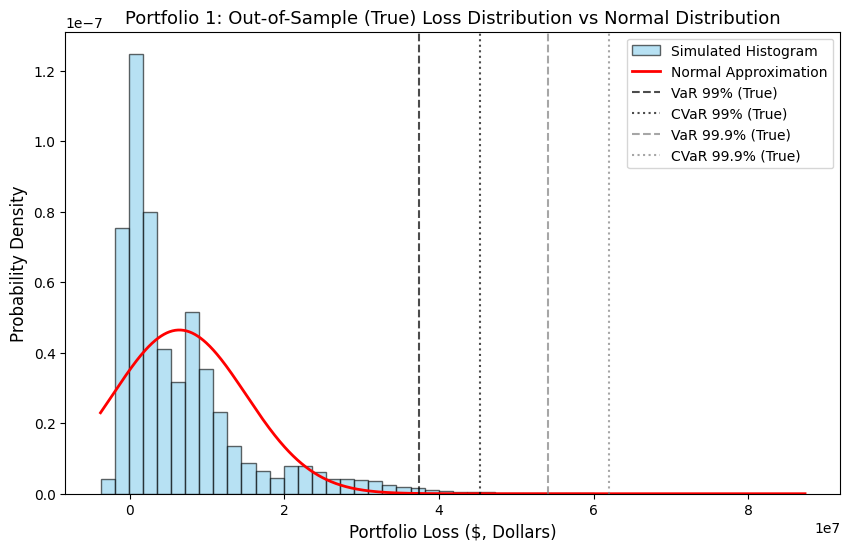

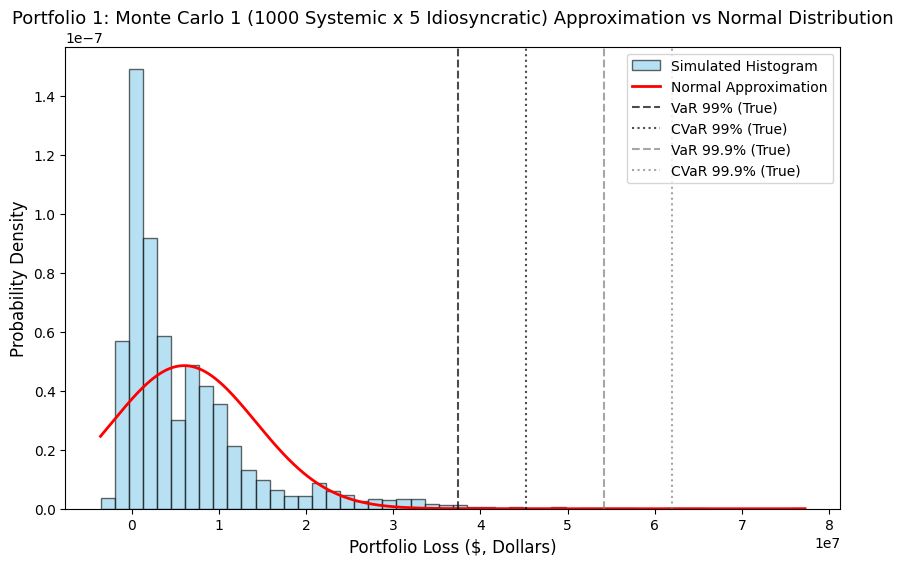

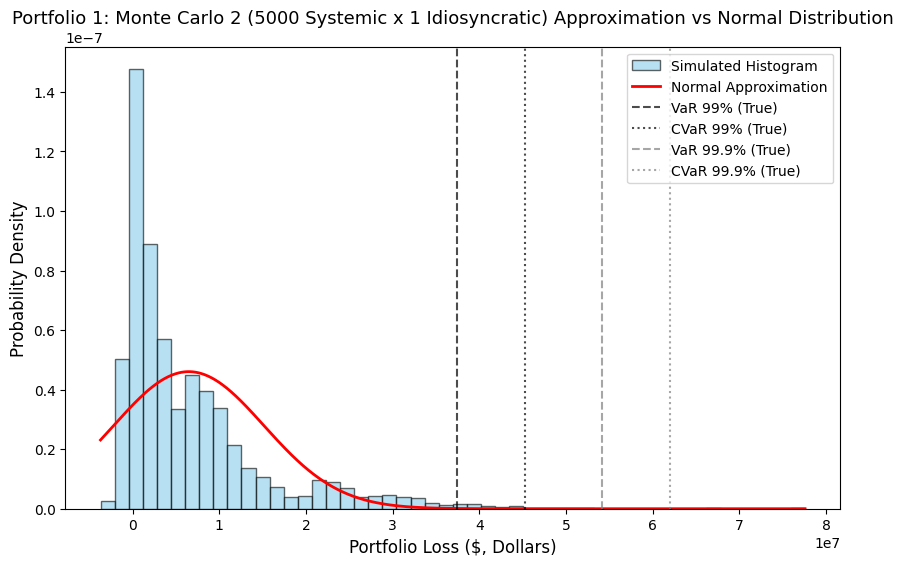

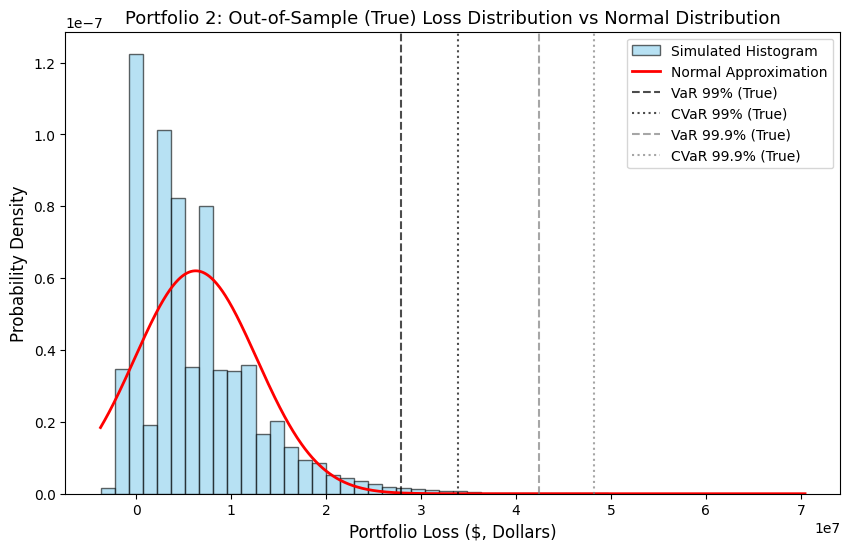

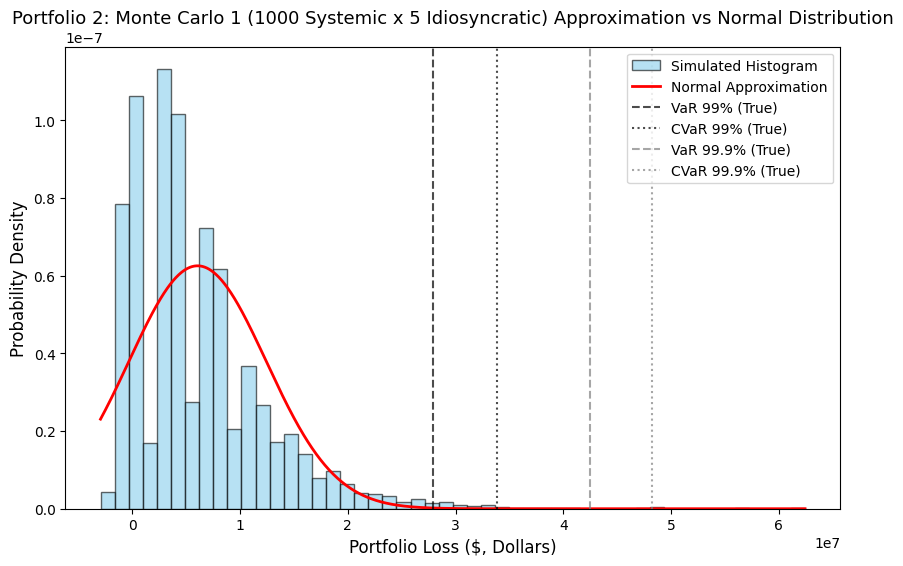

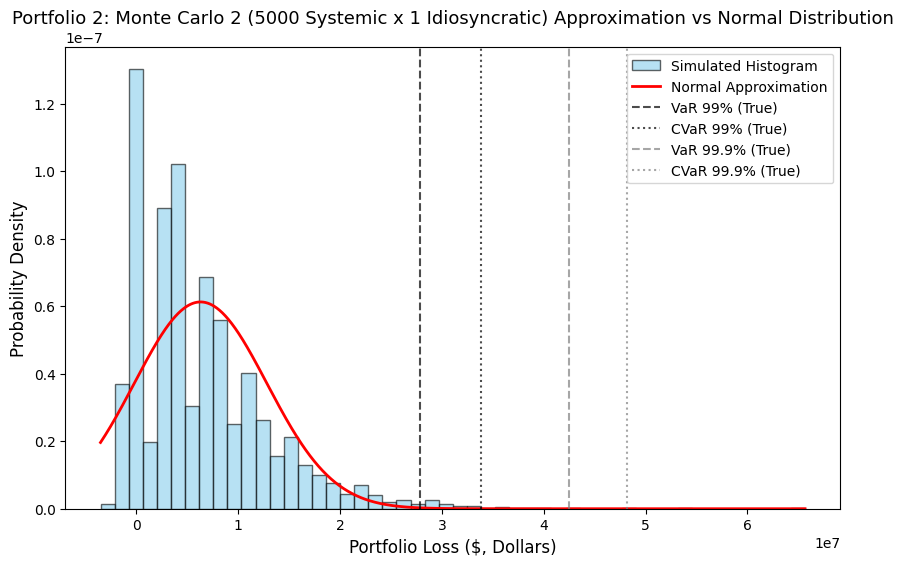

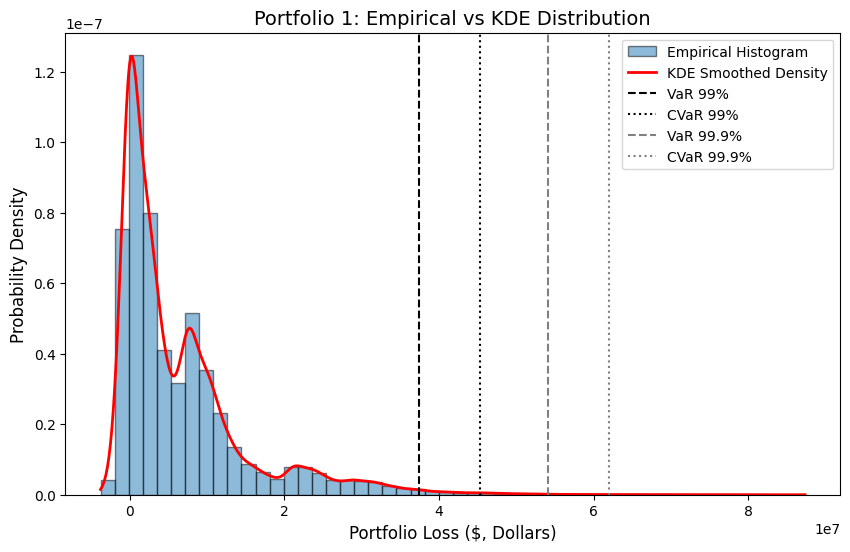

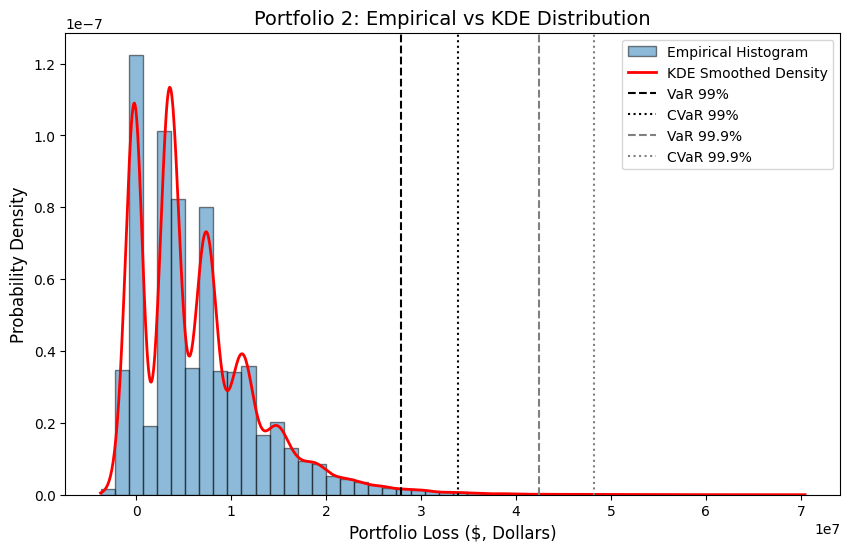

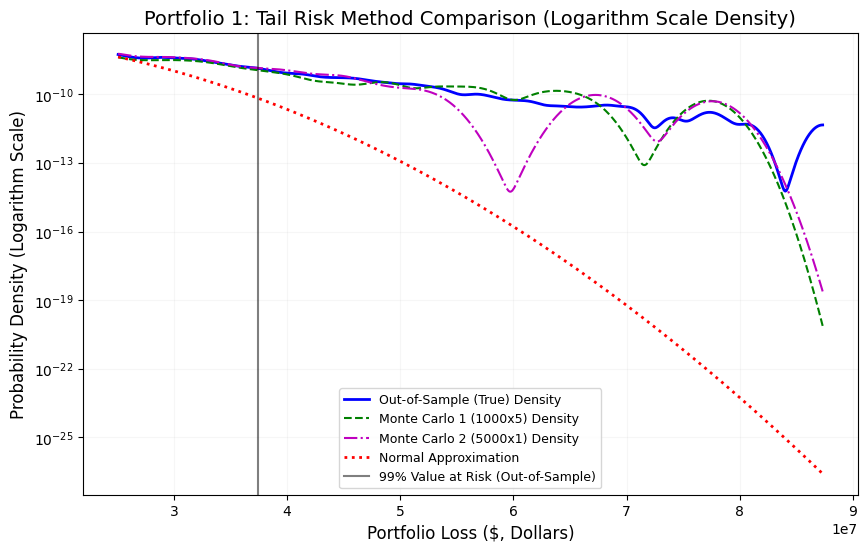

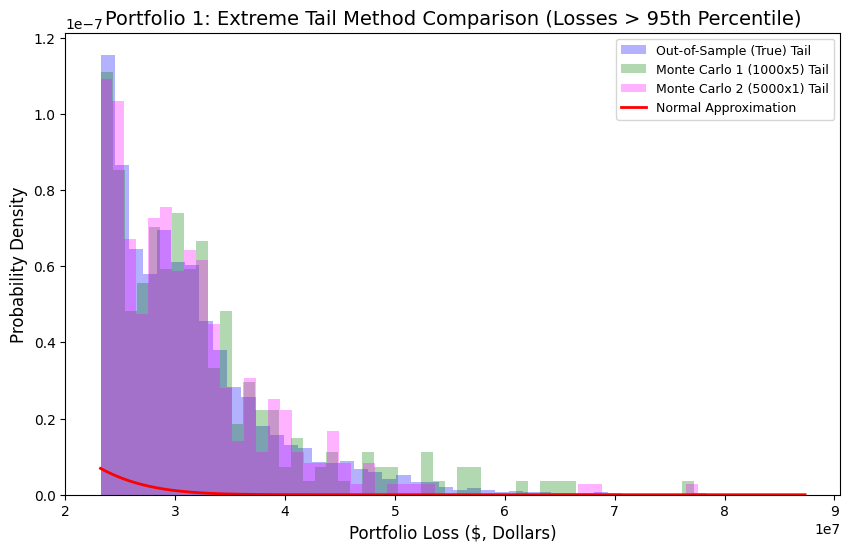

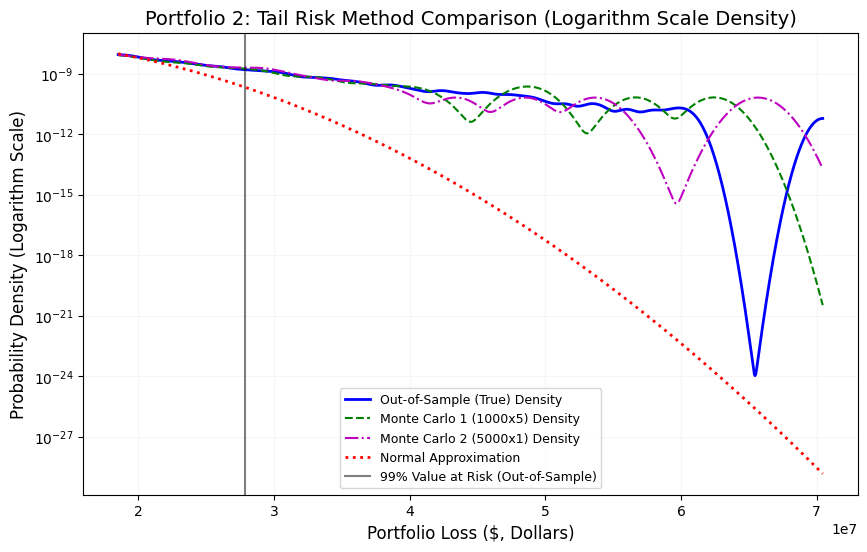

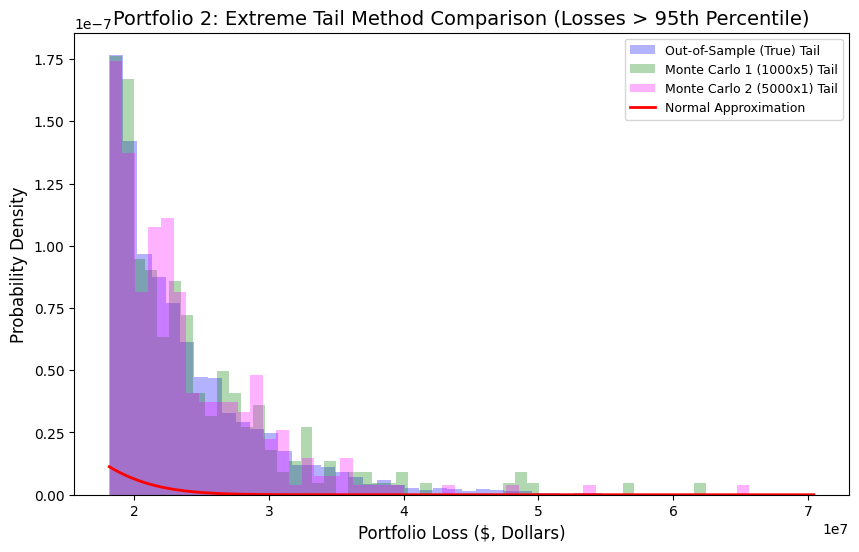


Monte Carlo Sampling Error
Portfolio Alpha     True VaR  MC Mean VaR   MC Std VaR  VaR % of True    True CVaR  MC Mean CVaR  MC Std CVaR  CVaR % of True Method
   Port 1 99.0% 3.744402e+07 3.711349e+07 1.401110e+06      99.117267 4.524178e+07  4.467563e+07 2.006795e+06       98.748607    MC1
   Port 1 99.0% 3.744402e+07 3.726418e+07 1.021969e+06      99.519705 4.524178e+07  4.490293e+07 1.528699e+06       99.251008    MC2
   Port 1 99.9% 5.413196e+07 5.366985e+07 4.100560e+06      99.146325 6.194389e+07  6.122393e+07 5.801431e+06       98.837721    MC1
   Port 1 99.9% 5.413196e+07 5.438819e+07 3.259227e+06     100.473344 6.194389e+07  6.190355e+07 4.712672e+06       99.934869    MC2
   Port 2 99.0% 2.786591e+07 2.743928e+07 1.196713e+06      98.468979 3.387658e+07  3.361810e+07 2.155345e+06       99.236982    MC1
   Port 2 99.0% 2.786591e+07 2.745414e+07 8.044537e+05      98.522300 3.387658e+07  3.358523e+07 1.315312e+06       99.139956    MC2
   Port 2 99.9% 4.246804e+07 4.169892e+07

In [22]:
# Distribution Plots For Both Portfolios (6 in total)
full_titles = [
    'Out-of-Sample (True) Loss Distribution',
    'Monte Carlo 1 (1000 Systemic x 5 Idiosyncratic) Approximation',
    'Monte Carlo 2 (5000 Systemic x 1 Idiosyncratic) Approximation'
]

for portN in range(2):
    # Prepare data for Out-of-Sample and the results from the last trial
    oos_data = np.array(Losses_out.dot(x0[portN])).flatten()

    # NOTE: Using the final trial from the 100 trials as a representative sample for visualization
    mc1_data = np.array(Losses_inMC1.dot(x0[portN])).flatten()
    mc2_data = np.array(Losses_inMC2.dot(x0[portN])).flatten()

    datasets = [oos_data, mc1_data, mc2_data]

    for i in range(3):
        # Portfolio statistics for the Normal curve overlay
        if i == 0:  # Out-of-sample
            mu_plot = np.dot(mu_l, x0[portN]).item()
            sigma_plot = np.sqrt(np.dot(x0[portN].T, np.dot(var_l, x0[portN]))).item()

        elif i == 1:  # MC1 (last trial)
            mu_MC1 = np.mean(L_trial1, axis=0)
            var_MC1 = np.cov(L_trial1, rowvar=False)
            mu_plot = np.dot(mu_MC1, x0[portN]).item()
            sigma_plot = np.sqrt(np.dot(x0[portN].T, np.dot(var_MC1, x0[portN]))).item()

        else:  # MC2
            mu_MC2 = np.mean(L_trial2, axis=0)
            var_MC2 = np.cov(L_trial2, rowvar=False)
            mu_plot = np.dot(mu_MC2, x0[portN]).item()
            sigma_plot = np.sqrt(np.dot(x0[portN].T, np.dot(var_MC2, x0[portN]))).item()

        plt.figure(figsize=(10, 6))
        plt.hist(datasets[i], bins=50, density=True, color='skyblue', edgecolor='black', alpha=0.6, label='Simulated Histogram')

        # Overlay the Theoretical Normal Approximation
        x_norm = np.linspace(min(datasets[i]), max(datasets[i]), 1000)
        plt.plot(x_norm, norm.pdf(x_norm, mu_plot, sigma_plot), 'r-', linewidth=2, label='Normal Approximation')

        # VaR and CVaR Markers (Out-of-Sample Ground Truth)
        plt.axvline(VaRout[portN, 0], color='black', linestyle='--', alpha=0.7, label='VaR 99% (True)')
        plt.axvline(CVaRout[portN, 0], color='black', linestyle=':', alpha=0.7, label='CVaR 99% (True)')
        plt.axvline(VaRout[portN, 1], color='grey', linestyle='--', alpha=0.7, label='VaR 99.9% (True)')
        plt.axvline(CVaRout[portN, 1], color='grey', linestyle=':', alpha=0.7, label='CVaR 99.9% (True)')

        # Labels and Titles with Units in Brackets
        plt.title(f'Portfolio {portN+1}: {full_titles[i]} vs Normal Distribution', fontsize=13)
        plt.xlabel('Portfolio Loss ($, Dollars)', fontsize=12)
        plt.ylabel('Probability Density', fontsize=12)
        plt.legend()
        plt.show()

# KDE vs Empirical Comparison Plot (Required for Discussion)
for portN in range(2):
    # Prepare Out-of-Sample dataset
    oos_data = np.array(Losses_out.dot(x0[portN])).flatten()

    plt.figure(figsize=(10, 6))

    # Histogram (Empirical Distribution)
    plt.hist(oos_data, bins=50, density=True, alpha=0.5, label='Empirical Histogram', edgecolor='black')

    # KDE Smoothed Distribution
    x_kde = np.linspace(min(oos_data), max(oos_data), 1000)
    plt.plot(x_kde, gaussian_kde(oos_data)(x_kde), 'r-', linewidth=2, label='KDE Smoothed Density')

    # VaR/CVaR Markers for comparison
    plt.axvline(VaRout[portN, 0], color='black', linestyle='--', label='VaR 99%')
    plt.axvline(CVaRout[portN, 0], color='black', linestyle=':', label='CVaR 99%')
    plt.axvline(VaRout[portN, 1], color='grey', linestyle='--', label='VaR 99.9%')
    plt.axvline(CVaRout[portN, 1], color='grey', linestyle=':', label='CVaR 99.9%')

    plt.title(f'Portfolio {portN+1}: Empirical vs KDE Distribution', fontsize=14)
    plt.xlabel('Portfolio Loss ($, Dollars)', fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.legend()
    plt.show()

# Tail Plots For Both Portfolios Which Include Logarithm Scale Density and Histogram Plot (4 in total)
for portN in range(2):
    # Prepare sorted datasets for Out-of-Sample, Monte Carlo 1, and Monte Carlo 2
    oos_data = np.sort(np.array(Losses_out.dot(x0[portN])).flatten())
    mc1_data = np.sort(np.array(Losses_inMC1.dot(x0[portN])).flatten())
    mc2_data = np.sort(np.array(Losses_inMC2.dot(x0[portN])).flatten())

    # Portfolio statistics for the Normal curve overlay
    mu_plot = np.dot(mu_l, x0[portN]).item()
    sigma_plot = np.sqrt(np.dot(x0[portN].T, np.dot(var_l, x0[portN]))).item()

    # Logarithm Overlay (Comparing Sampling Error and Model Error)
    plt.figure(figsize=(10, 6))
    x_range = np.linspace(np.percentile(oos_data, 95), max(oos_data), 1000)

    # Plot Kernel Density Estimations (KDE) for all simulation methods
    plt.plot(x_range, gaussian_kde(oos_data)(x_range), 'b-', linewidth=2, label='Out-of-Sample (True) Density')
    plt.plot(x_range, gaussian_kde(mc1_data)(x_range), 'g--', linewidth=1.5, label='Monte Carlo 1 (1000x5) Density')
    plt.plot(x_range, gaussian_kde(mc2_data)(x_range), 'm-.', linewidth=1.5, label='Monte Carlo 2 (5000x1) Density')

    # Plot the Normal Approximation
    plt.plot(x_range, norm.pdf(x_range, mu_plot, sigma_plot), 'r:', linewidth=2, label='Normal Approximation')

    plt.yscale('log')
    plt.axvline(VaRout[portN, 0], color='black', linestyle='-', alpha=0.5, label='99% Value at Risk (Out-of-Sample)')

    plt.title(f'Portfolio {portN+1}: Tail Risk Method Comparison (Logarithm Scale Density)', fontsize=14)
    plt.xlabel('Portfolio Loss ($, Dollars)', fontsize=12)
    plt.ylabel('Probability Density (Logarithm Scale)', fontsize=12)
    plt.legend(fontsize=9)
    plt.grid(True, which="both", ls="-", alpha=0.1)
    plt.show()

    # Tail Overlay (Direct Comparison of Extreme Losses > 95th Percentile)
    tail_cutoff = min(
        np.percentile(oos_data, 95),
        np.percentile(mc1_data, 95),
        np.percentile(mc2_data, 95)
    )

    plt.figure(figsize=(10, 6))
    plt.hist(oos_data[oos_data > tail_cutoff], bins=50, density=True, alpha=0.3, label='Out-of-Sample (True) Tail', color='blue')
    plt.hist(mc1_data[mc1_data > tail_cutoff], bins=50, density=True, alpha=0.3, label='Monte Carlo 1 (1000x5) Tail', color='green')
    plt.hist(mc2_data[mc2_data > tail_cutoff], bins=50, density=True, alpha=0.3, label='Monte Carlo 2 (5000x1) Tail', color='magenta')

    x_zoom = np.linspace(tail_cutoff, max(oos_data), 500)
    plt.plot(x_zoom, norm.pdf(x_zoom, mu_plot, sigma_plot), 'r-', linewidth=2, label='Normal Approximation')

    plt.title(f'Portfolio {portN+1}: Extreme Tail Method Comparison (Losses > 95th Percentile)', fontsize=14)
    plt.xlabel('Portfolio Loss ($, Dollars)', fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.legend(fontsize=9)
    plt.show()

# Analysis Tables
# Table 1: Monte Carlo approximations (16 rows)
# Approximate 100000 scenario True distribution
df_mc = pd.DataFrame({})
columns_mc = ["Portfolio", "Alpha", "True VaR", "MC Mean VaR", "MC Std VaR", "VaR % of True", "True CVaR", "MC Mean CVaR", "MC Std CVaR", "CVaR % of True", "Method"]
mc_data = []

for portN in range(2):
    for q in range(alphas.size):
        for method in ['MC1', 'MC2']:
            # Grab the 100 trial results for the current method
            trial_vars = VaRinMC1[portN, q] if method == 'MC1' else VaRinMC2[portN, q]
            trial_cvars = CVaRinMC1[portN, q] if method == 'MC1' else CVaRinMC2[portN, q]

            # Average the results across 100 trials to find the expected estimate
            m_v, m_c = np.mean(trial_vars), np.mean(trial_cvars)

            # Calculate standard deviation to quantify the sampling noise or stability of the method
            m_std_v, m_std_c = np.std(trial_vars), np.std(trial_cvars)

            # Benchmark against the 100k-scenario ground truth
            true_var, true_cvar = VaRout[portN, q], CVaRout[portN, q]

            mc_data.append([
                f"Port {portN+1}", f"{alphas[q]*100}%", true_var, m_v, m_std_v,
                (m_v / true_var) * 100, true_cvar, m_c, m_std_c, (m_c / true_cvar) * 100, method
            ])
df_mc = pd.DataFrame(mc_data, columns=columns_mc)

# Table 2: Normal approximations (16 rows)
# Compares Normal approximations against the True non-normal distribution
df_N = pd.DataFrame({})
n_data = []
for portN in range(2):
    for q in range(alphas.size):
        for suffix in ['1', '2']:
            # Pull the Normal estimates derived from either MC1 or MC2 trial stats
            trial_n_vars = VaRinN1[portN, q] if suffix == '1' else VaRinN2[portN, q]
            trial_n_cvars = CVaRinN1[portN, q] if suffix == '1' else CVaRinN2[portN, q]

            # Find the average Normal estimate across 100 trials
            n_v, n_c = np.mean(trial_n_vars), np.mean(trial_n_cvars)
            n_std_v, n_std_c = np.std(trial_n_vars), np.std(trial_n_cvars)

            true_var, true_cvar = VaRout[portN, q], CVaRout[portN, q]

            n_data.append([
                f"Port {portN+1}", f"{alphas[q]*100}%", true_var, n_v, n_std_v,
                (n_v / true_var) * 100, true_cvar, n_c, n_std_c, (n_c / true_cvar) * 100, f"Normal (N{suffix})"
            ])
df_N = pd.DataFrame(n_data, columns=columns_mc)

print("\nMonte Carlo Sampling Error")
print(df_mc.to_string(index=False))
print("\nNormal Model Error")
print(df_N.to_string(index=False))